# Critical Mineral Trade Analysis on South America - Prospective Team

## Authors: Ohm Patel, Michelle Thomas, Edwin Zhang

# Setup of pandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("south_america_cleaned.csv")

df.head()

/Users/michellethomas/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


,HS Code,Commodity Name,Year,Month,Country,Nominal Value,Annual Inflation Rate,CPI,Real Value,Category Type
0,2504,Natural Graphite,2014,May,Argentina,19158,1.62,108.5634,17646.831253,Ore / Raw
1,2504,Natural Graphite,2021,Jan,Argentina,5750,4.70,124.2543,4627.606449,Ore / Raw
2,2504,Natural Graphite,2010,Jan,Brazil,402305,1.64,100.0000,402305.000000,Ore / Raw
3,2504,Natural Graphite,2010,Feb,Brazil,228508,1.64,100.0000,228508.000000,Ore / Raw
4,2504,Natural Graphite,2010,Mar,Brazil,458104,1.64,100.0000,458104.000000,Ore / Raw


# Commodity Level Analysis

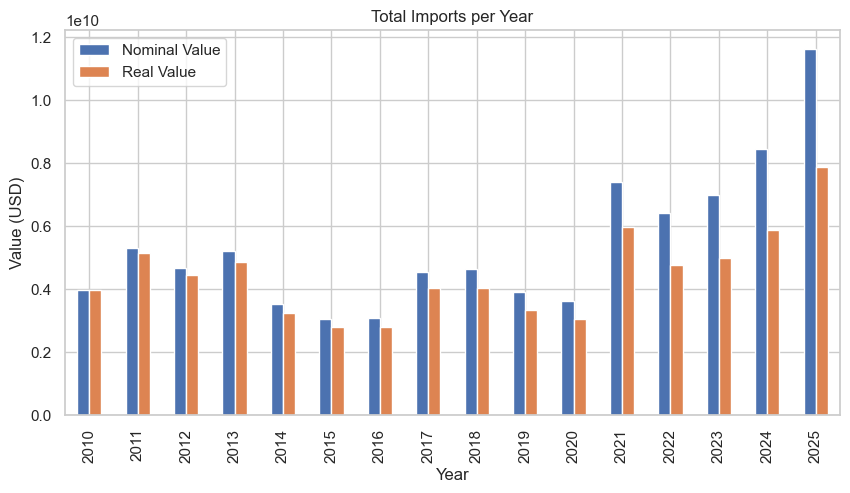

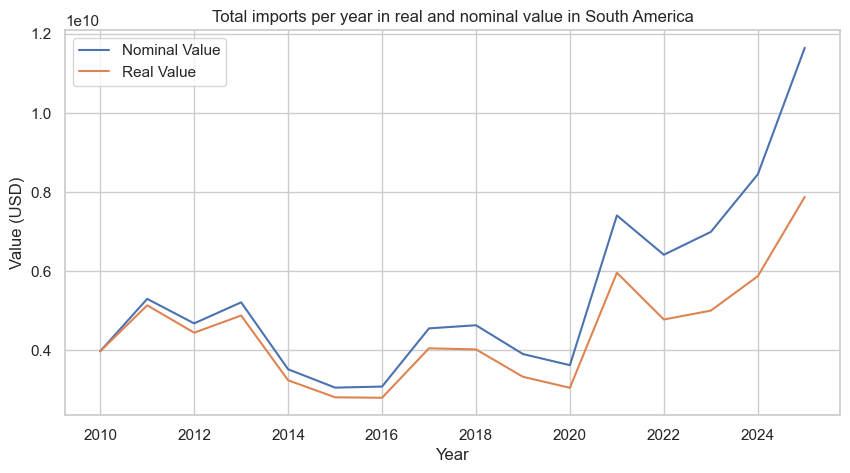

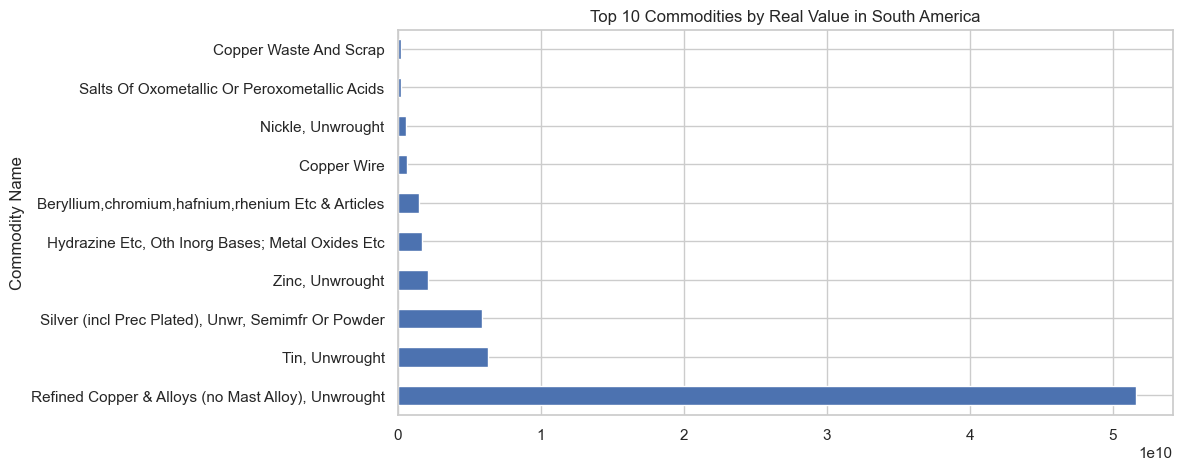

Commodity Name
Refined Copper & Alloys (no Mast Alloy), Unwrought    72.371155
Tin, Unwrought                                         8.839246
Silver (incl Prec Plated), Unwr, Semimfr Or Powder     8.224218
Zinc, Unwrought                                        2.944878
Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc       2.344902
Name: Real Value, dtype: float64
Combined Share: 94.72%


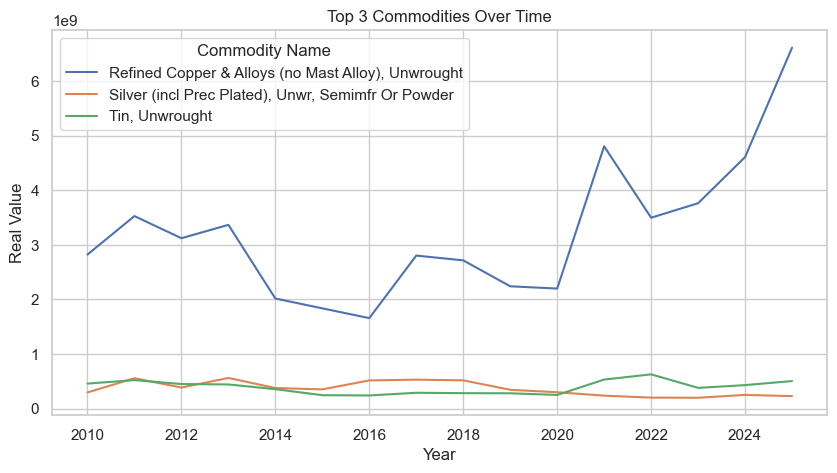

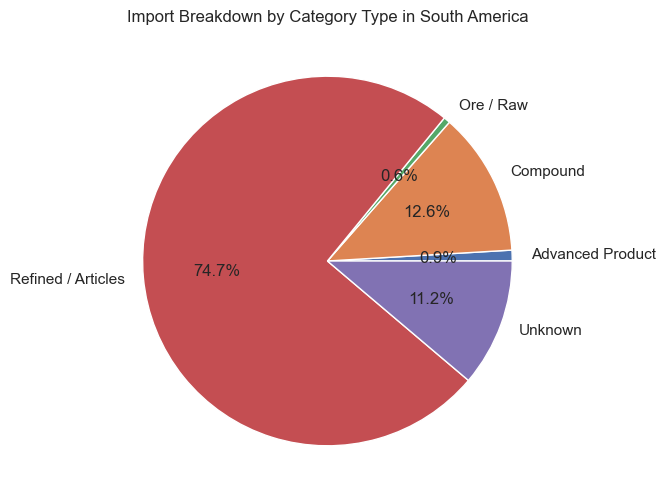

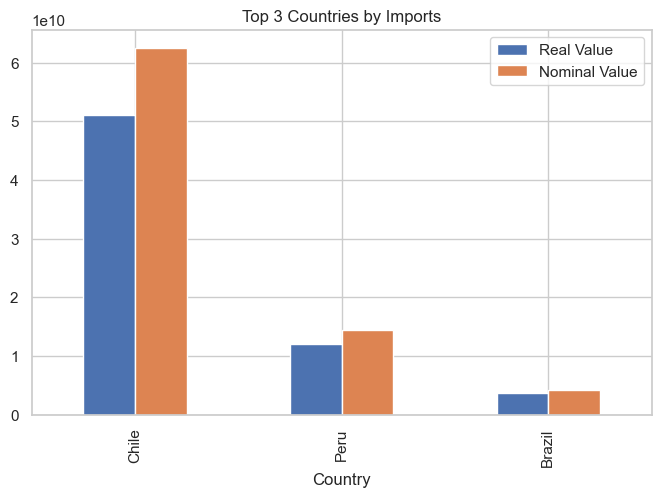

Country
Chile     71.557628
Peru      17.008282
Brazil     5.154217
Name: Real Value, dtype: float64
Combined Share: 93.72%


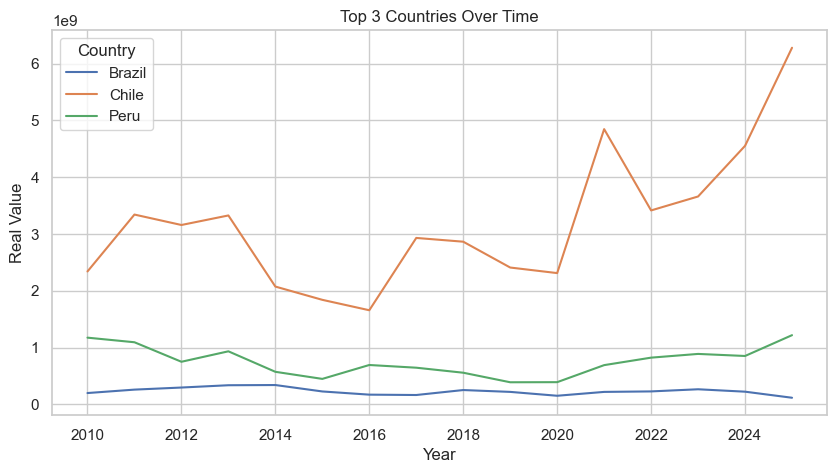

,Country,Commodity Name,Real Value
0,Brazil,"Beryllium,chromium,hafnium,rhenium Etc & Articles",8.603609e+08
22,Brazil,"Tin, Unwrought",7.944289e+08
7,Brazil,"Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc",7.413048e+08
32,Chile,"Refined Copper & Alloys (no Mast Alloy), Unwro...",4.762515e+10
34,Chile,"Silver (incl Prec Plated), Unwr, Semimfr Or Po...",1.661025e+09
30,Chile,"Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc",7.248503e+08
47,Peru,"Refined Copper & Alloys (no Mast Alloy), Unwro...",3.790386e+09
50,Peru,"Tin, Unwrought",3.359898e+09
48,Peru,"Silver (incl Prec Plated), Unwr, Semimfr Or Po...",2.271392e+09


In [2]:
## Bar Plot — Total Imports Per Year
yearly = df.groupby("Year")[["Nominal Value", "Real Value"]].sum()

yearly.plot(kind="bar", figsize=(10,5))
plt.title("Total Imports per Year")
plt.ylabel("Value (USD)")
plt.show()


##Yearly Trend (Line Plot)
yearly.plot(figsize=(10,5))
plt.title("Total imports per year in real and nominal value in South America")
plt.ylabel("Value (USD)")
plt.xlabel("Year")
plt.show()


##Top 10 Commodities (Real Value)
top10 = (
    df.groupby("Commodity Name")["Real Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top10.plot(kind="barh", figsize=(10,5))
plt.title("Top 10 Commodities by Real Value in South America")
plt.show()


## % Share of Top 5 Commodities
total_real = df["Real Value"].sum()

top5 = top10.head(5)
percent_share = (top5 / total_real) * 100

print(percent_share)
print(f"Combined Share: {percent_share.sum():.2f}%")


##Time Series — Top 3 Commodities (Year-Based)
top3_names = top10.head(3).index

top3_df = df[df["Commodity Name"].isin(top3_names)]

ts = top3_df.groupby(["Year", "Commodity Name"])["Real Value"].sum().unstack()

ts.plot(figsize=(10,5))
plt.title("Top 3 Commodities Over Time")
plt.ylabel("Real Value")
plt.show()


##Category Type Distribution (Pie Chart)
category = df.groupby("Category Type")["Real Value"].sum()

category.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Import Breakdown by Category Type in South America")
plt.ylabel("")
plt.show()


##Top 3 Countries (Bar Plot)
top_countries = (
    df.groupby("Country")[["Real Value", "Nominal Value"]]
    .sum()
    .sort_values(by="Real Value", ascending=False)
    .head(3)
)

top_countries.plot(kind="bar", figsize=(8,5))
plt.title("Top 3 Countries by Imports")
plt.show()


## % Share of Top 3 Countries
total_real = df["Real Value"].sum()

country_share = (top_countries["Real Value"] / total_real) * 100

print(country_share)
print(f"Combined Share: {country_share.sum():.2f}%")


##Time Series — Top 3 Countries (Year-Based)
top3_country_names = top_countries.index

country_ts = (
    df[df["Country"].isin(top3_country_names)]
    .groupby(["Year", "Country"])["Real Value"]
    .sum()
    .unstack()
)

country_ts.plot(figsize=(10,5))
plt.title("Top 3 Countries Over Time")
plt.ylabel("Real Value")
plt.show()


##Top Commodities per Top Countries
subset = df[df["Country"].isin(top3_country_names)]

top_country_commodities = (
    subset.groupby(["Country", "Commodity Name"])["Real Value"]
    .sum()
    .reset_index()
)

top_country_commodities = top_country_commodities.sort_values(
    ["Country", "Real Value"], ascending=[True, False]
)

top_country_commodities.groupby("Country").head(3)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

plt.rcParams["figure.figsize"] =  (12, 6)

df = pd.read_csv("south_america_cleaned.csv")

# build YearMonth datetime column from separate Year and Month cols
df["Month"] = pd.to_datetime(df["Month"], format="%b").dt.month
df["YearMonth"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df = df.sort_values("YearMonth").reset_index(drop=True)

# helper column: real Value in thousands (mirrors other team's convention)
df["Real_Value_Thousands"] = df["Real Value"] / 1_000
df.head()

,HS Code,Commodity Name,Year,Month,Country,Nominal Value,Annual Inflation Rate,CPI,Real Value,Category Type,YearMonth,Real_Value_Thousands
0,2825,"Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc",2010,1,Bolivia,855318,1.64,100.0,855318.0,Unknown,2010-01-01,855.318
1,7408,Copper Wire,2010,1,Peru,1177187,1.64,100.0,1177187.0,Advanced Product,2010-01-01,1177.187
2,7403,"Refined Copper & Alloys (no Mast Alloy), Unwro...",2010,1,Peru,60799903,1.64,100.0,60799903.0,Refined / Articles,2010-01-01,60799.903
3,7403,"Refined Copper & Alloys (no Mast Alloy), Unwro...",2010,1,Chile,302650361,1.64,100.0,302650361.0,Refined / Articles,2010-01-01,302650.361
4,7106,"Silver (incl Prec Plated), Unwr, Semimfr Or Po...",2010,1,Colombia,988697,1.64,100.0,988697.0,Unknown,2010-01-01,988.697


## Seasonality Analysis

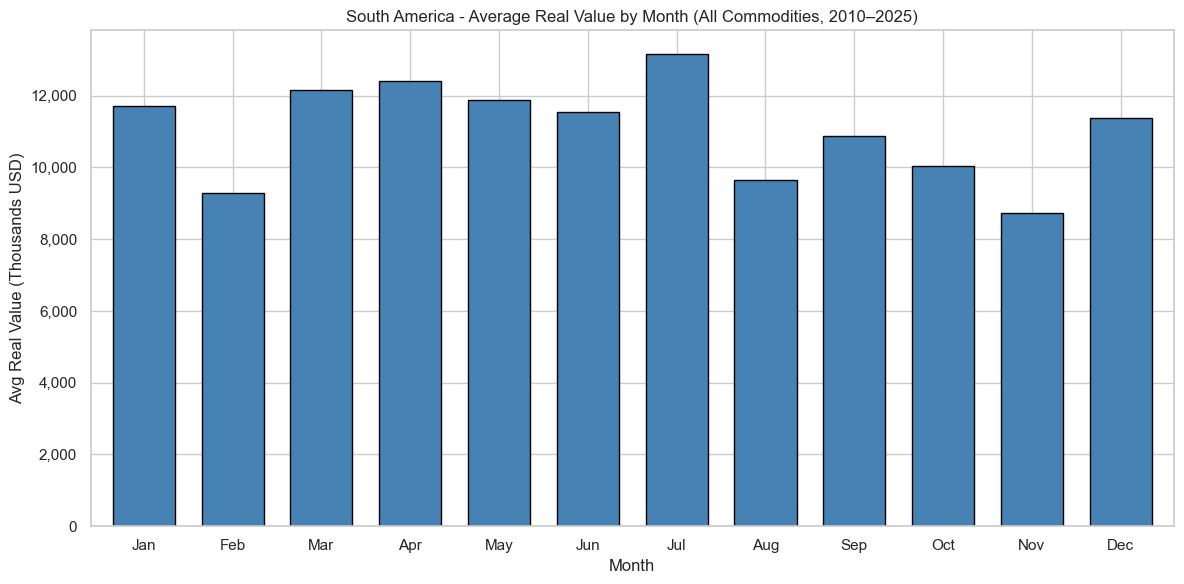

In [4]:
# seasonality: avg monthly real value across all years
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_avg = (
    df.groupby("Month")["Real_Value_Thousands"]
    .mean()
    .reindex(range(1, 13))
)

ax = monthly_avg.plot(kind="bar", color="steelblue", edgecolor="black", width=0.7)
ax.set_title("South America - Average Real Value by Month (All Commodities, 2010–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Real Value (Thousands USD)")
ax.set_xticklabels(month_labels, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

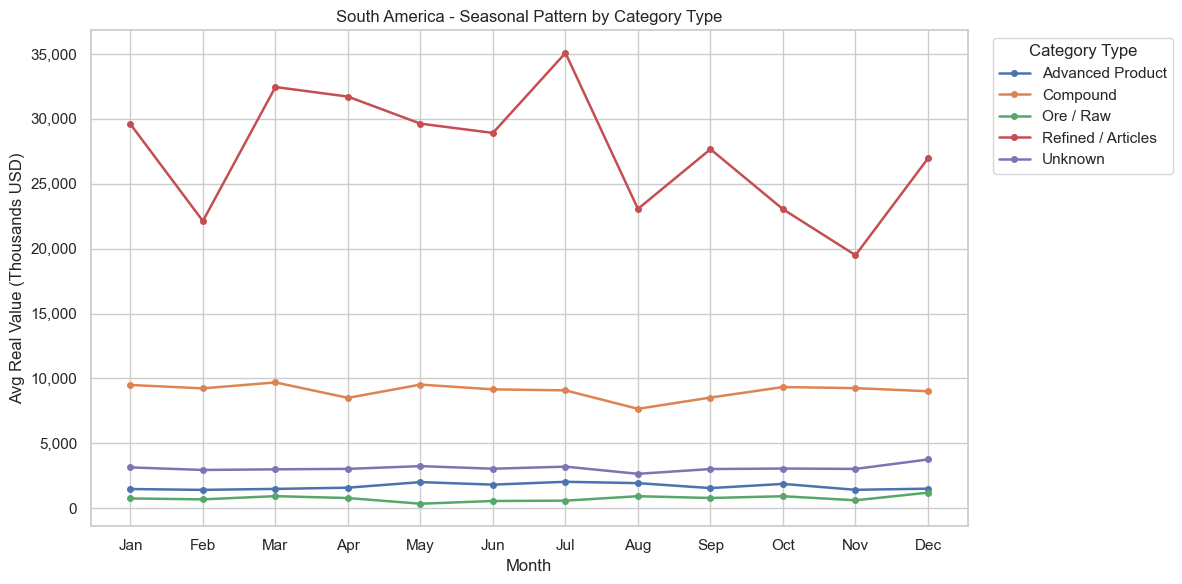

In [5]:
# seasonality: monthly pattern broken out by category type 
monthly_cat = (
    df.groupby(["Month", "Category Type"])["Real_Value_Thousands"]
    .mean()
    .unstack()
    .reindex(range(1, 13))
)

monthly_cat.plot(linewidth=1.8, marker="o", markersize=4)
plt.title("South America - Seasonal Pattern by Category Type")
plt.xlabel("Month")
plt.ylabel("Avg Real Value (Thousands USD)")
plt.xticks(range(1, 13), month_labels, rotation=0)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="Category Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

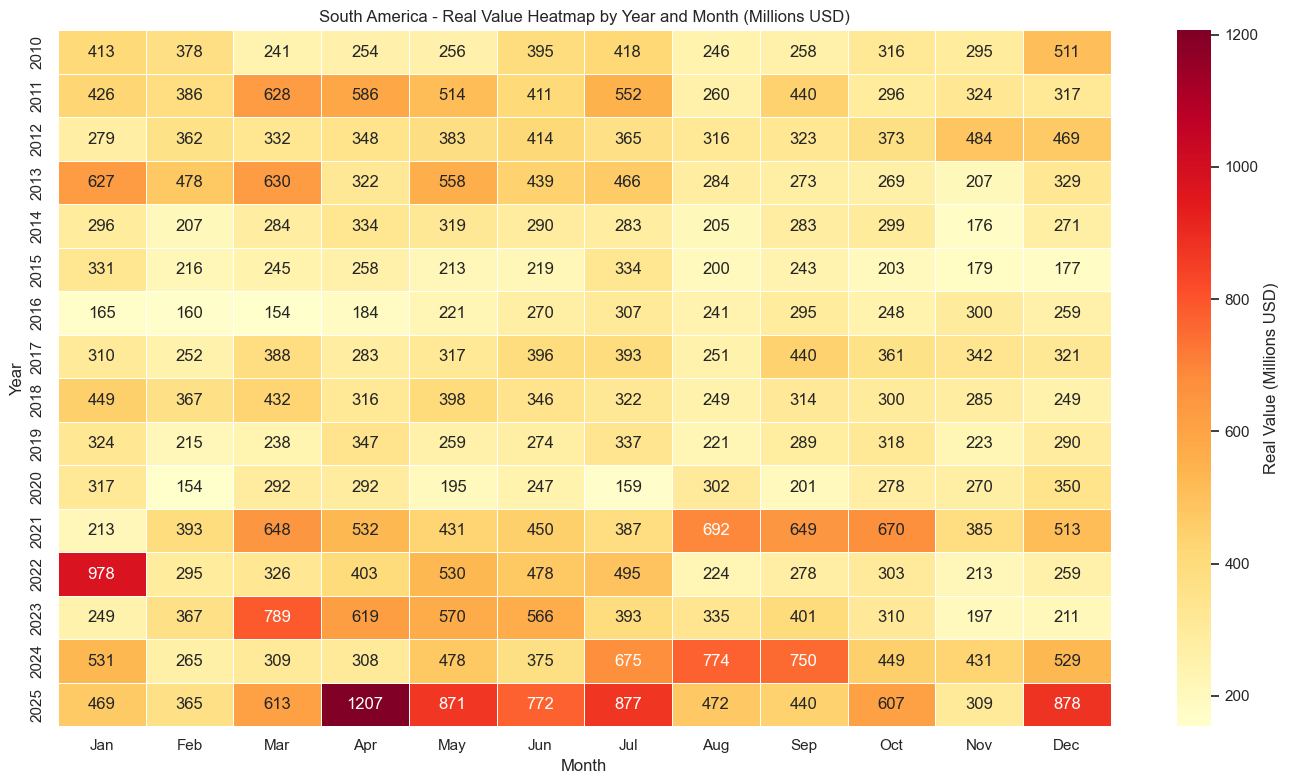

In [6]:
# Seasonality Heatmap of Year x Month total real value (millions) 
# useful for spotting which year-month combinations were unusually high/low
heatmap_data = (
    df.groupby(["Year", "Month"])["Real Value"]
    .sum()
    .unstack()
    / 1_000_000  # display in millions - readability
)
heatmap_data.columns = month_labels

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap= "YlOrRd",
    linewidths= 0.4,
    annot= True,
    fmt= ".0f",
    cbar_kws= {"label": "Real Value (Millions USD)"}
)
plt.title("South America - Real Value Heatmap by Year and Month (Millions USD)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

## Month-over-Month (MoM) Analysis

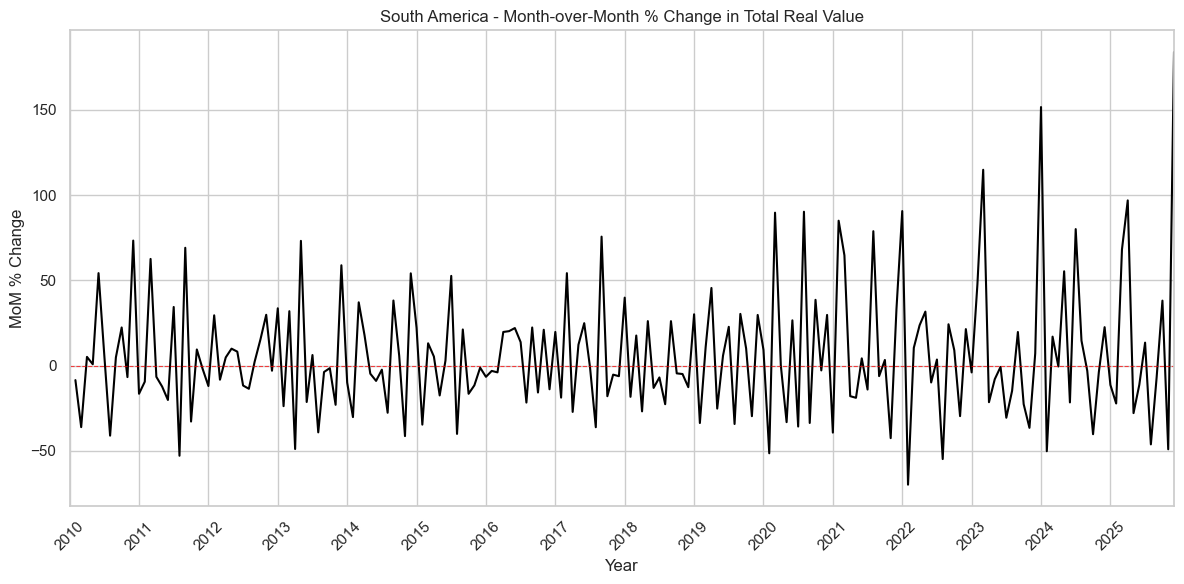

In [7]:
# MoM: Overall % change across all South America commodities
monthly_total = (
    df.groupby("YearMonth")["Real_Value_Thousands"]
    .sum()
    .sort_index()
)

mom_pct = monthly_total.pct_change() * 100

ax = mom_pct.plot(color="black", linewidth=1.5)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("South America - Month-over-Month % Change in Total Real Value")
ax.set_xlabel("Year")
ax.set_ylabel("MoM % Change")

years = pd.date_range(start=mom_pct.index.min(), end=mom_pct.index.max(), freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.tight_layout()
plt.show()

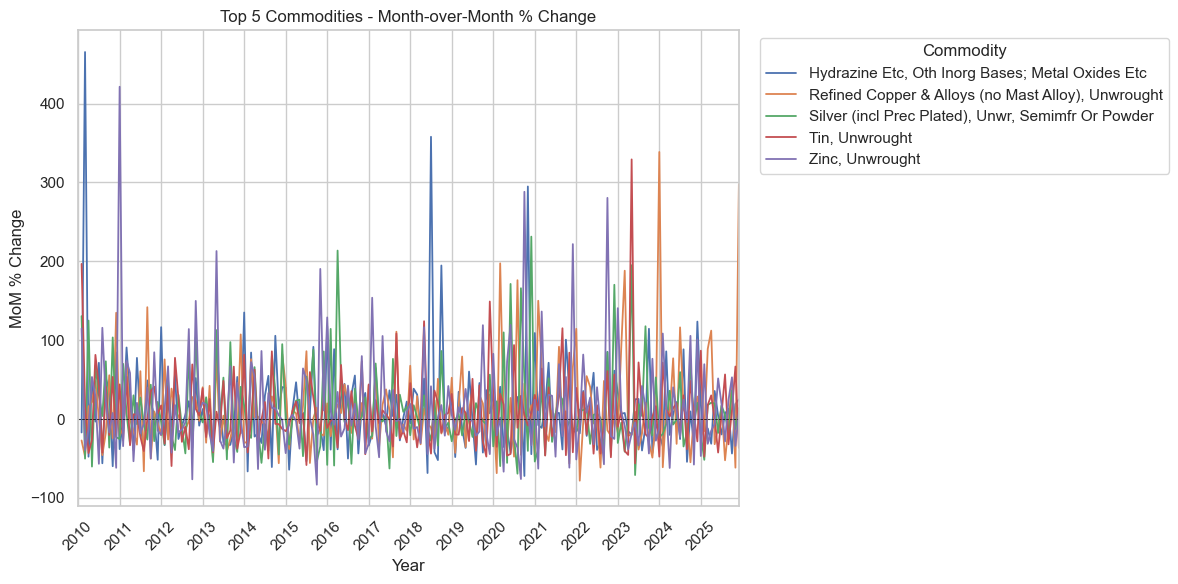

In [8]:
# MoM: Top 5 commodities by total real value
top5_commodities = (
    df.groupby("Commodity Name")["Real Value"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

top5_df = df[df["Commodity Name"].isin(top5_commodities)]

top5_mom = (
    top5_df.groupby(["YearMonth", "Commodity Name"])["Real_Value_Thousands"]
    .sum()
    .unstack()
    .sort_index()
    .pct_change() * 100
)

top5_mom.plot(linewidth=1.3)
plt.title("Top 5 Commodities - Month-over-Month % Change")
plt.xlabel("Year")
plt.ylabel("MoM % Change")
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)

years = pd.date_range(start=top5_mom.index.min(), end=top5_mom.index.max(), freq="YS")
plt.gca().set_xticks(years)
plt.gca().set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Commodity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Year-over-Year (YoY) Analysis

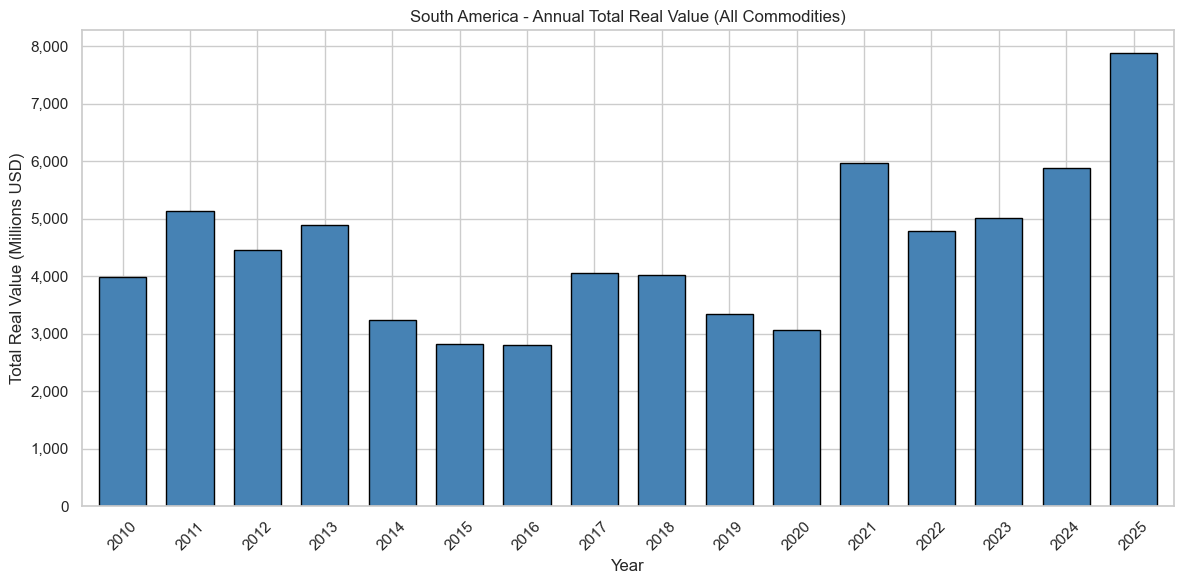

In [9]:
# YoY: annual total real value (bar chart) 
annual_total = (
    df.groupby("Year")["Real Value"]
    .sum()
    / 1_000_000  # millions
)

ax = annual_total.plot(kind="bar", color="steelblue", edgecolor="black", width=0.7)
ax.set_title("South America - Annual Total Real Value (All Commodities)")
ax.set_xlabel("Year")
ax.set_ylabel("Total Real Value (Millions USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

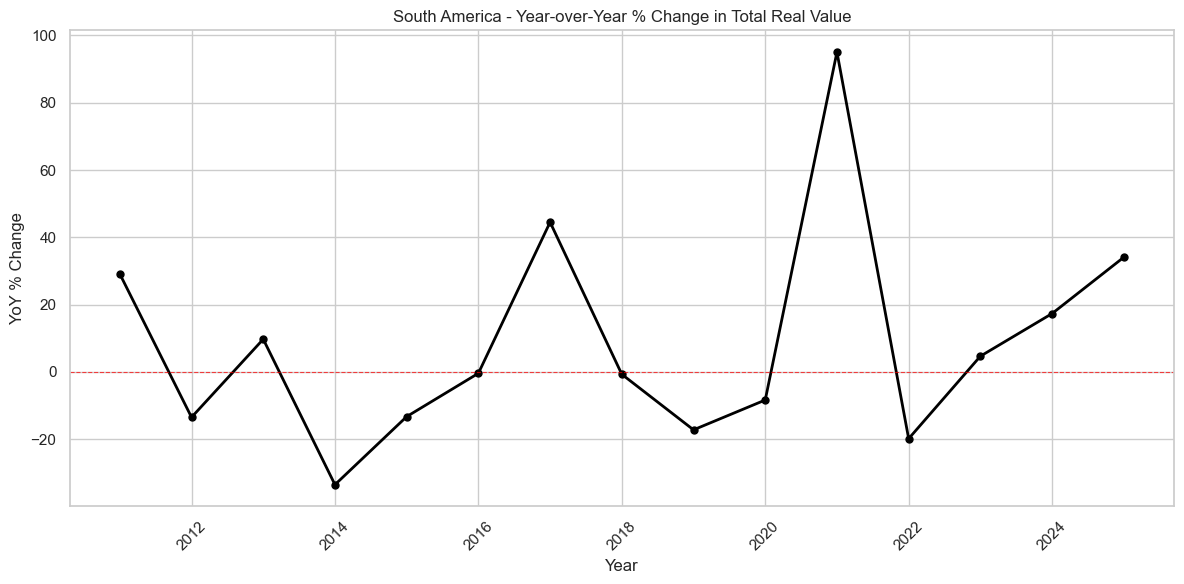

In [10]:
#YoY:overall % change year-over-year
yoy_pct = annual_total.pct_change() * 100

ax = yoy_pct.plot(color="black", linewidth=2, marker="o", markersize=5)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("South America - Year-over-Year % Change in Total Real Value")
ax.set_xlabel("Year")
ax.set_ylabel("YoY % Change")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

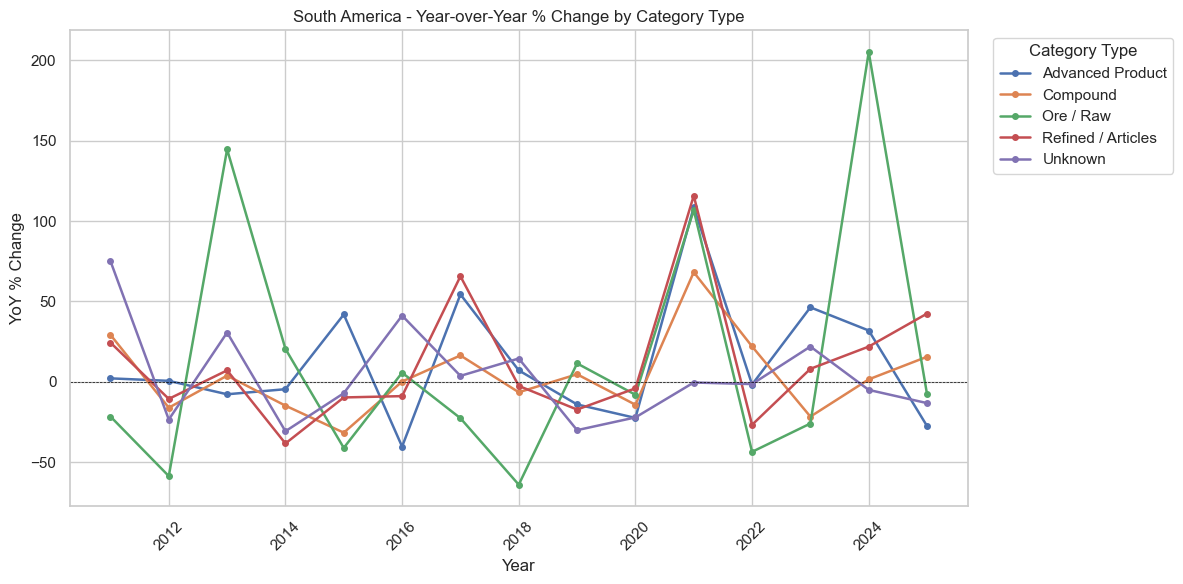

In [11]:
# YoY: percentage change broken out by Category Type 
annual_cat = (
    df.groupby(["Year", "Category Type"])["Real Value"]
    .sum()
    .unstack()
    / 1_000_000
)

annual_cat_yoy = annual_cat.pct_change() * 100

annual_cat_yoy.plot(linewidth=1.8, marker="o", markersize=4)
plt.title("South America - Year-over-Year % Change by Category Type")
plt.xlabel("Year")
plt.ylabel("YoY % Change")
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)
plt.legend(title="Category Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

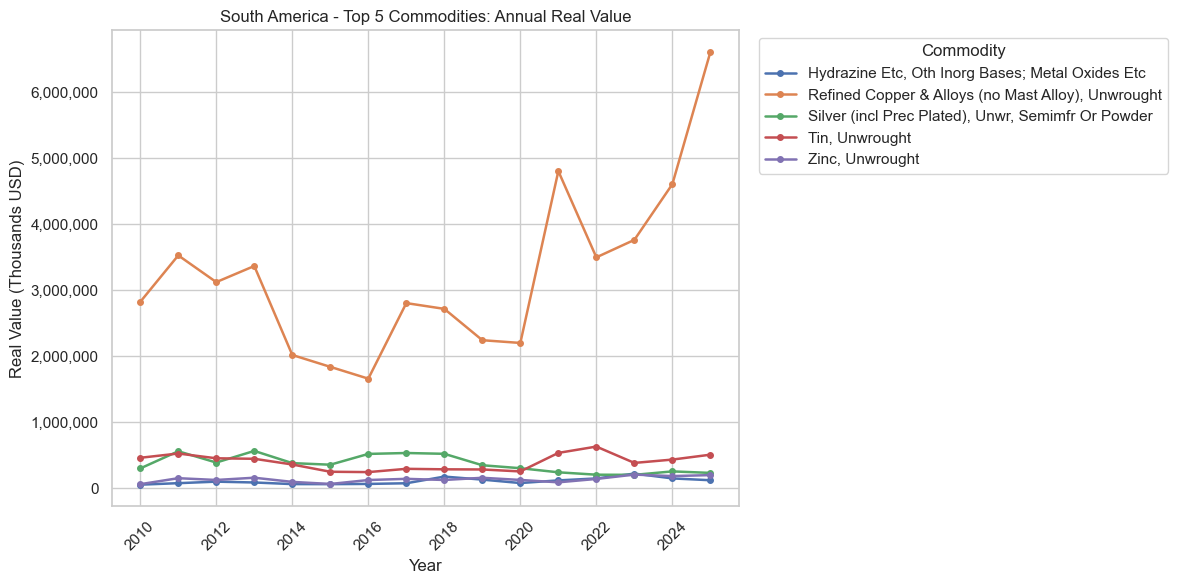

In [12]:
# YoY: top 5 commodities absolute annual value (line chart)
# mirrors the other team's per-commodity trend line charts
top5_annual = (
    df[df["Commodity Name"].isin(top5_commodities)]
    .groupby(["Year", "Commodity Name"])["Real_Value_Thousands"]
    .sum()
    .unstack()
    .sort_index()
)

top5_annual.plot(linewidth=1.8, marker="o", markersize=4)
plt.title("South America - Top 5 Commodities: Annual Real Value")
plt.xlabel("Year")
plt.ylabel("Real Value (Thousands USD)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.legend(title="Commodity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12-Month Rolling Average
Monthly trade values have cluttered data (nuisance variables) — the rolling average reveals structural trends more clearly, especially around the 2015–16 commodity downturn and 2020 COVID shock.

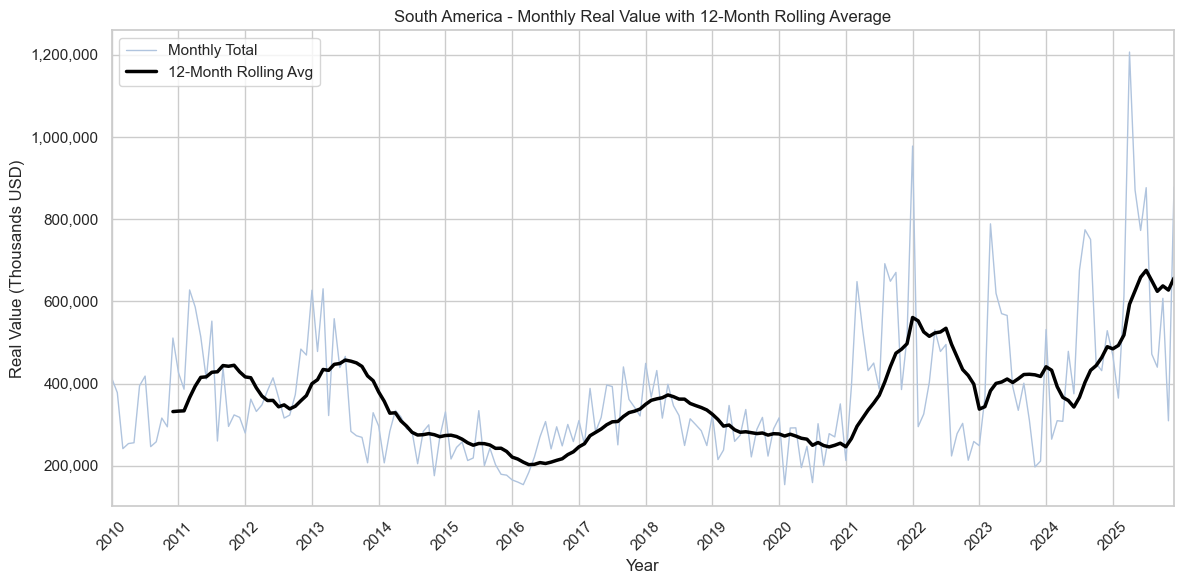

In [13]:
# monthly total with 12-month rolling average overlay
monthly_total_k = (
    df.groupby("YearMonth")["Real_Value_Thousands"]
    .sum()
    .sort_index()
)

rolling_12 = monthly_total_k.rolling(window=12).mean()

ax = monthly_total_k.plot(color="lightsteelblue", linewidth=1, label="Monthly Total")
rolling_12.plot(ax=ax, color="black", linewidth=2.5, label="12-Month Rolling Avg")

years = pd.date_range(start=monthly_total_k.index.min(), end=monthly_total_k.index.max(), freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

ax.set_title("South America - Monthly Real Value with 12-Month Rolling Average")
ax.set_xlabel("Year")
ax.set_ylabel("Real Value (Thousands USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

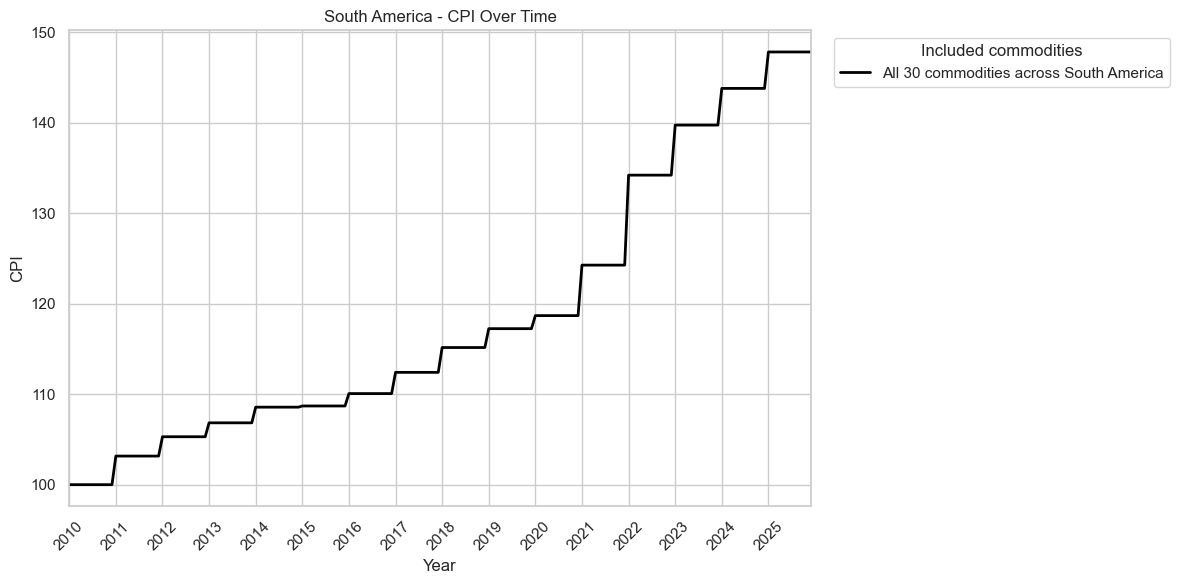

In [14]:
# CPI over time (all South America commodities)
all_label = f"All {df['Commodity Name'].nunique()} commodities across South America"

cpi_over_time = (
    df.groupby("YearMonth")["CPI"]
    .mean()
    .sort_index()
)

ax = cpi_over_time.plot(color="black", linewidth=2, label=all_label)
ax.set_title("South America - CPI Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("CPI")

years = pd.date_range(start=cpi_over_time.index.min(), end=cpi_over_time.index.max(), freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

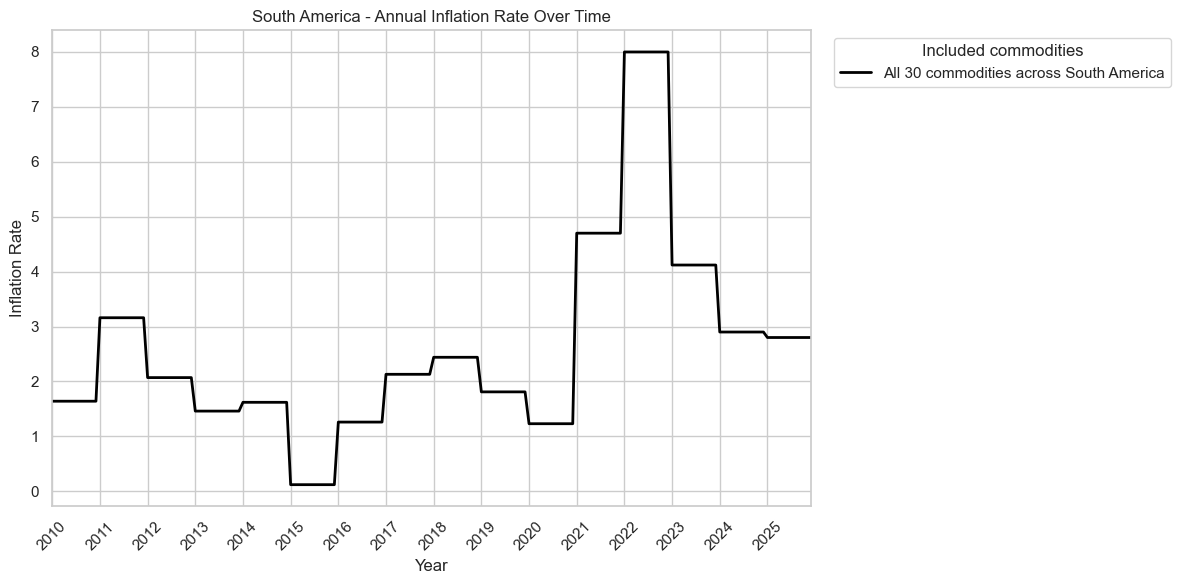

In [15]:
# inflation Rate over time (all South America commodities)
inflation_over_time = (
    df.groupby("YearMonth")["Annual Inflation Rate"]
    .mean()
    .sort_index()
)

ax = inflation_over_time.plot(color="black", linewidth=2, label=all_label)
ax.set_title("South America - Annual Inflation Rate Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Inflation Rate")

years = pd.date_range(start=inflation_over_time.index.min(), end=inflation_over_time.index.max(), freq="YS")
ax.set_xticks(years)
ax.set_xticklabels([d.strftime("%Y") for d in years], rotation=45)

plt.legend(title="Included commodities", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

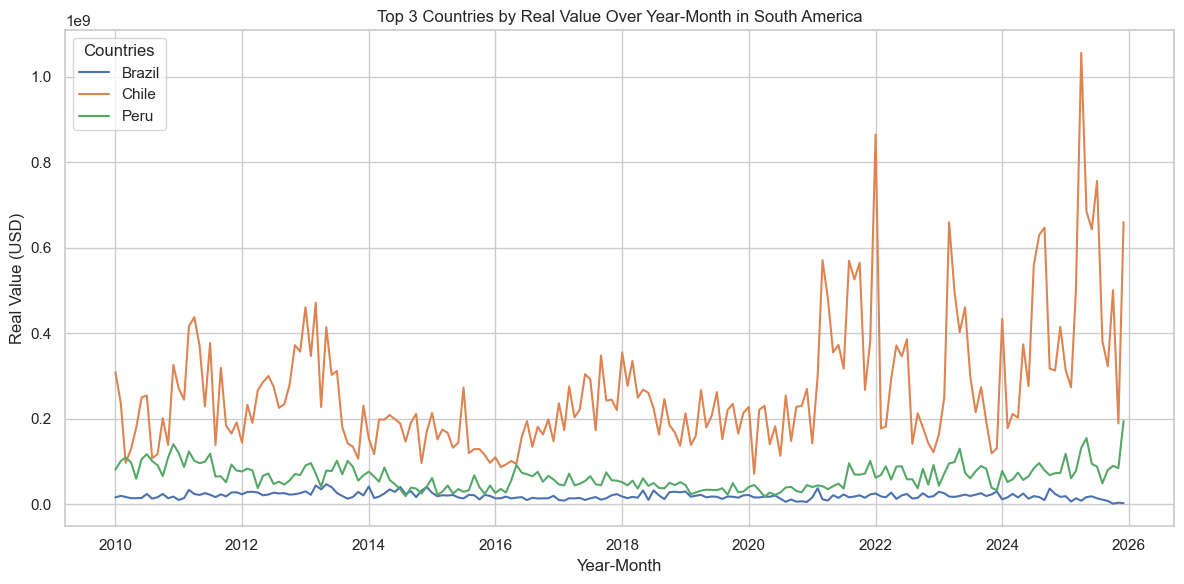

In [16]:
top3_country_names = (
    df.groupby("Country")["Real Value"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

country_ts = (
    df[df["Country"].isin(top3_country_names)]
    .groupby(["YearMonth", "Country"])["Real Value"]
    .sum()
    .unstack()
    .sort_index()
)

plt.figure(figsize=(12, 6))
for country in country_ts.columns:
    plt.plot(country_ts.index, country_ts[country], label=country, linewidth=1.5)

plt.title("Top 3 Countries by Real Value Over Year-Month in South America")
plt.xlabel("Year-Month")
plt.ylabel("Real Value (USD)")
plt.legend(title="Countries")
plt.tight_layout()
plt.show()

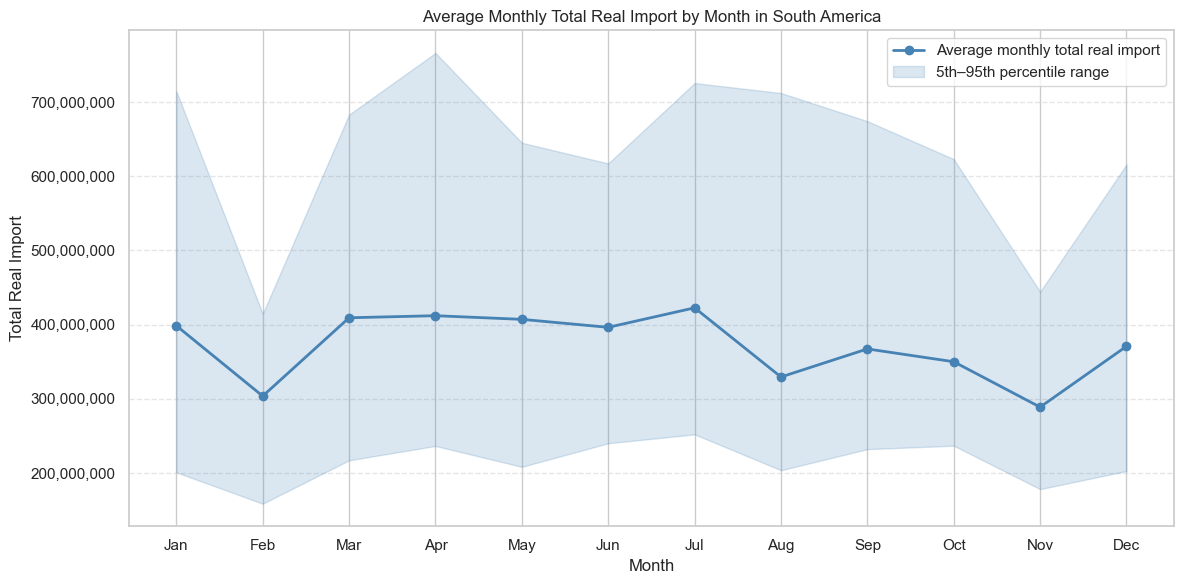

In [17]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# group by Year+Month to get monthly totals per year, then summarize across years
monthly_by_year = (
    df.groupby(["Year", "Month"])["Real Value"]
    .sum()
    .reset_index()
)

monthly_stats = monthly_by_year.groupby("Month")["Real Value"].agg(
    mean="mean",
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95)
)
monthly_stats.index = month_order

plt.figure(figsize=(12, 6))
plt.plot(month_order, monthly_stats["mean"], marker="o", linewidth=2, label="Average monthly total real import", color="steelblue")
plt.fill_between(month_order, monthly_stats["p5"], monthly_stats["p95"], alpha=0.2, color="steelblue", label="5th–95th percentile range")

plt.title("Average Monthly Total Real Import by Month in South America")
plt.xlabel("Month")
plt.ylabel("Total Real Import")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

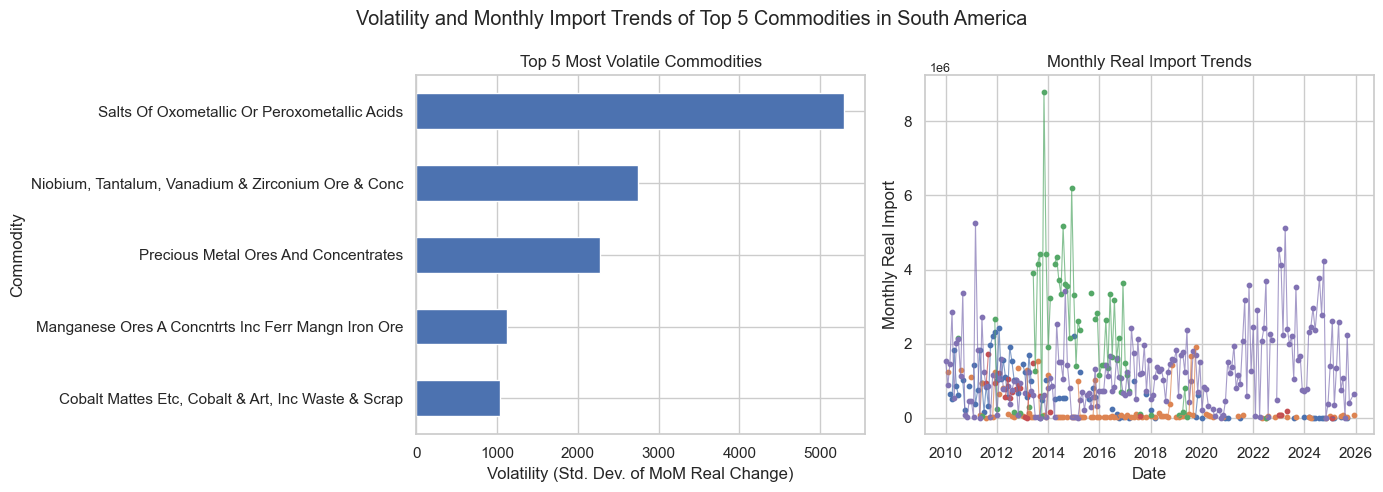

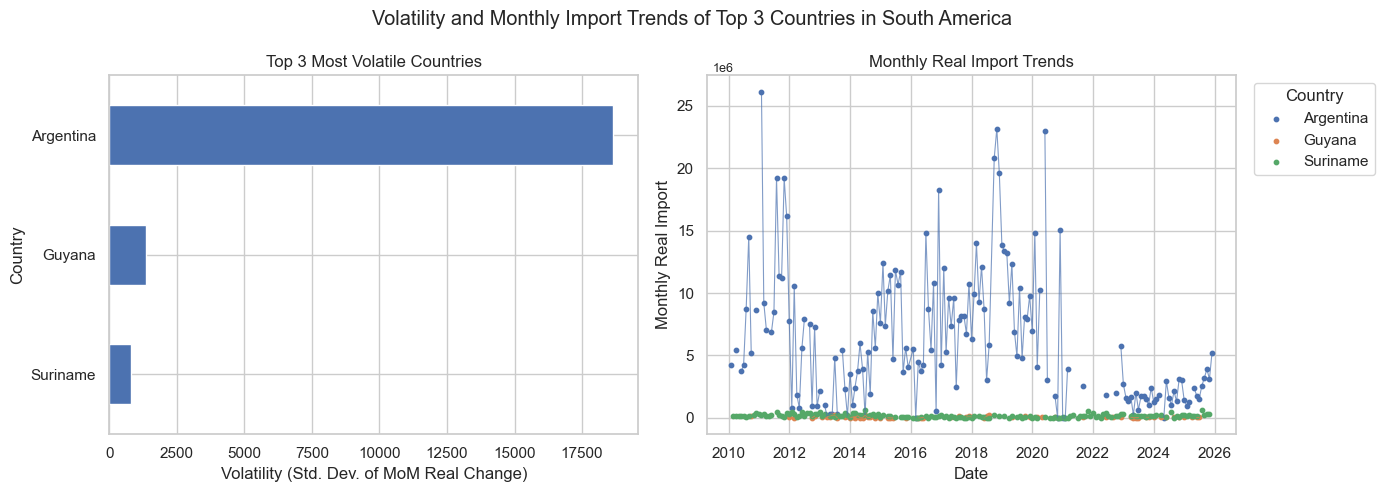

In [18]:
# ── Volatility: Top 5 Commodities ──────────────────────────────────────────
mom_commodity = (
    df.groupby(["YearMonth", "Commodity Name"])["Real Value"]
    .sum()
    .unstack()
    .sort_index()
    .pct_change() * 100
)

volatility_commodity = mom_commodity.std().sort_values(ascending=False).head(5)

top5_vol_names = volatility_commodity.index.tolist()
top5_vol_ts = (
    df[df["Commodity Name"].isin(top5_vol_names)]
    .groupby(["YearMonth", "Commodity Name"])["Real Value"]
    .sum()
    .unstack()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Volatility and Monthly Import Trends of Top 5 Commodities in South America")

# left: horizontal bar
volatility_commodity[::-1].plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 5 Most Volatile Commodities")
axes[0].set_xlabel("Volatility (Std. Dev. of MoM Real Change)")
axes[0].set_ylabel("Commodity")

# right: scatter/line per commodity
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, col in enumerate(top5_vol_ts.columns):
    axes[1].plot(top5_vol_ts.index, top5_vol_ts[col], linewidth=0.8,
                 color=colors[i], alpha=0.7)
    axes[1].scatter(top5_vol_ts.index, top5_vol_ts[col], s=10,
                    color=colors[i])

axes[1].set_title("Monthly Real Import Trends")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Monthly Real Import")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))
axes[1].text(0.01, 1.01, "1e6", transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
plt.show()


# ── Volatility: Top 3 Countries ────────────────────────────────────────────
mom_country = (
    df.groupby(["YearMonth", "Country"])["Real Value"]
    .sum()
    .unstack()
    .sort_index()
    .pct_change() * 100
)

volatility_country = mom_country.std().sort_values(ascending=False).head(3)

top3_vol_country_names = volatility_country.index.tolist()
top3_vol_country_ts = (
    df[df["Country"].isin(top3_vol_country_names)]
    .groupby(["YearMonth", "Country"])["Real Value"]
    .sum()
    .unstack()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Volatility and Monthly Import Trends of Top 3 Countries in South America")

# left: horizontal bar
volatility_country[::-1].plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 3 Most Volatile Countries")
axes[0].set_xlabel("Volatility (Std. Dev. of MoM Real Change)")
axes[0].set_ylabel("Country")

# right: scatter/line per country
for i, col in enumerate(top3_vol_country_ts.columns):
    axes[1].plot(top3_vol_country_ts.index, top3_vol_country_ts[col],
                 linewidth=0.8, color=colors[i], alpha=0.7)
    axes[1].scatter(top3_vol_country_ts.index, top3_vol_country_ts[col],
                    s=10, color=colors[i], label=col)

axes[1].set_title("Monthly Real Import Trends")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Monthly Real Import")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))
axes[1].text(0.01, 1.01, "1e6", transform=axes[1].transAxes, fontsize=9)
axes[1].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()